# 🏥 Healthcare Patient Analytics

This project demonstrates Exploratory Data Analysis (EDA)
on healthcare patient data.

## IMPORT REQUIRED And Load DataSet
A DataFrame is like an Excel table in Python. pd.read_csv() loads CSV data into a Pandas DataFrame.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("healthcare_patient_analytics_seaborn.csv")

## RANDOM SAMPLING
Why use sampling?

Large datasets may contain thousands of rows.
Plotting everything can:
- Slow down visualization
- Make graphs crowded

So we randomly select 500 rows.

In [3]:
ds = df.sample(500)

In [4]:
# SET SEABORN THEME
sns.set_theme(style="dark")

## Treatment Cost vs Recovery Score (SCATTER PLOT)
`hue="visit_type"`: Adds different colors for different visit categories. Each dot represents one patient.


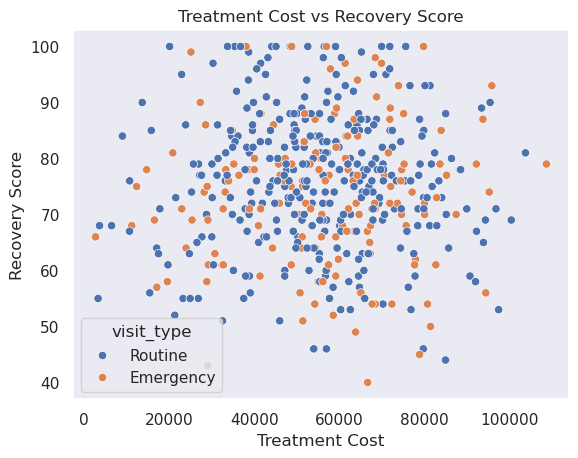

In [5]:
sns.scatterplot(
    data=ds,
    x="treatment_cost",
    y="recovery_score",
    hue="visit_type"
)

plt.title("Treatment Cost vs Recovery Score")
plt.xlabel("Treatment Cost")
plt.ylabel("Recovery Score")
plt.savefig("Treatment Cost vs Recovery Score (Scatter Plot by visit type)",dpi=100)
plt.show()

## Treatment Cost vs Recovery Score (Relational Plot by gender)

`col="gender":`
Creates separate graphs for:
- Male
- Female

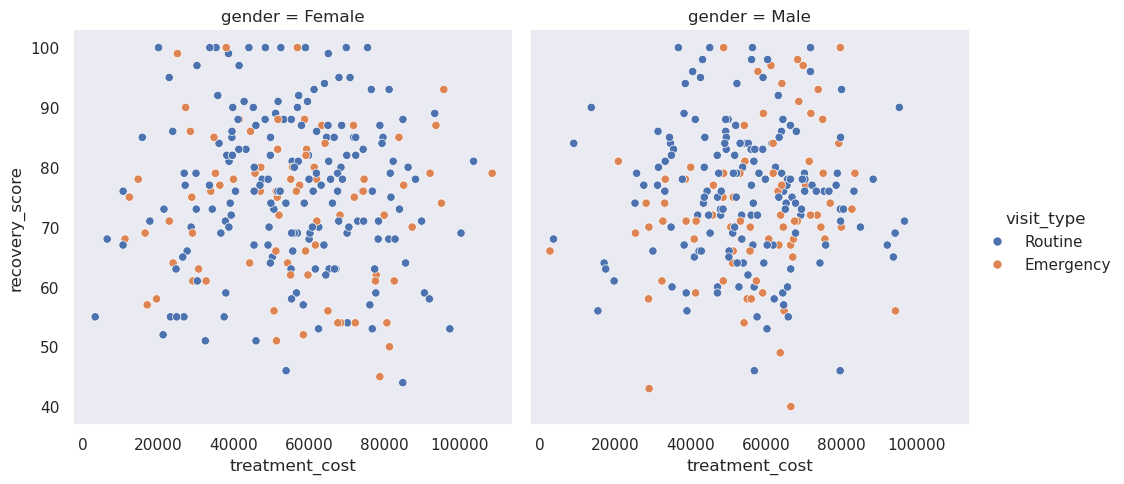

In [6]:
sns.relplot(
    data=ds,
    x="treatment_cost",
    y="recovery_score",
    hue="visit_type",
    col="gender"
)
plt.savefig("Treatment Cost vs Recovery Score (relational plot by gender)",dpi=100)
plt.show()

## Difference between Matplotlib and SeaBorn (Scatter Plots)

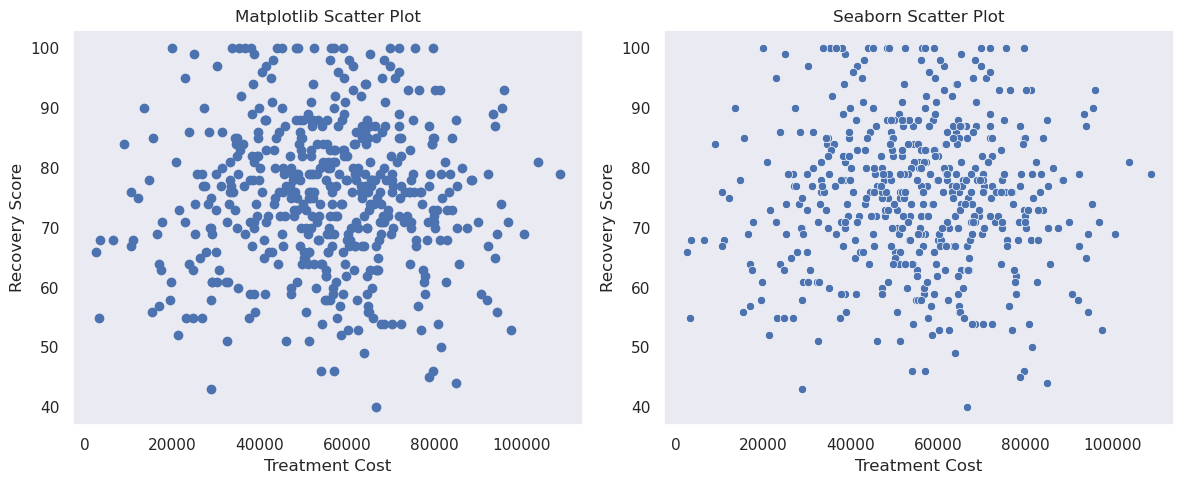

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matplotlib Scatter Plot
axes[0].scatter(
    ds["treatment_cost"],
    ds["recovery_score"]
)

axes[0].set_xlabel("Treatment Cost")
axes[0].set_ylabel("Recovery Score")
axes[0].set_title("Matplotlib Scatter Plot")

# 2. Seaborn Scatter Plot
sns.scatterplot(
    data=ds,
    x="treatment_cost",
    y="recovery_score",
    ax=axes[1]
)

axes[1].set_xlabel("Treatment Cost")
axes[1].set_ylabel("Recovery Score")
axes[1].set_title("Seaborn Scatter Plot")

plt.tight_layout()
plt.savefig("scatter_comparison.png", dpi=100)
plt.show()

## Distribution of Treatment Cost (Histogram)

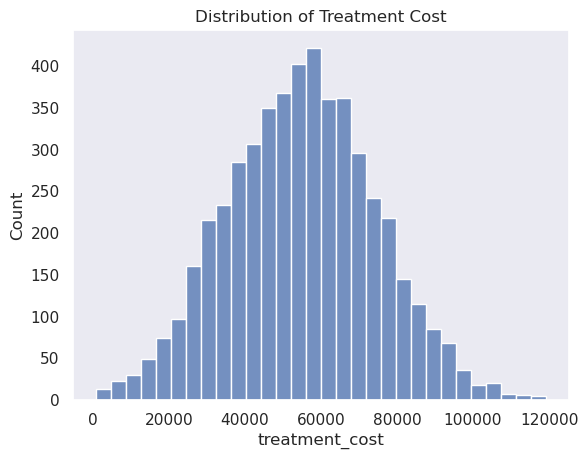

In [8]:
sns.histplot(
    data=df,
    x="treatment_cost",
    bins=30
)
plt.title("Distribution of Treatment Cost")
plt.savefig("Distribution of Treatment Cost",dpi=100)
plt.show()

## Readmission Risk by Visit Type (STACKED HISTOGRAM)

`Readmission Risk:` Probability that a patient may need
hospital admission again.

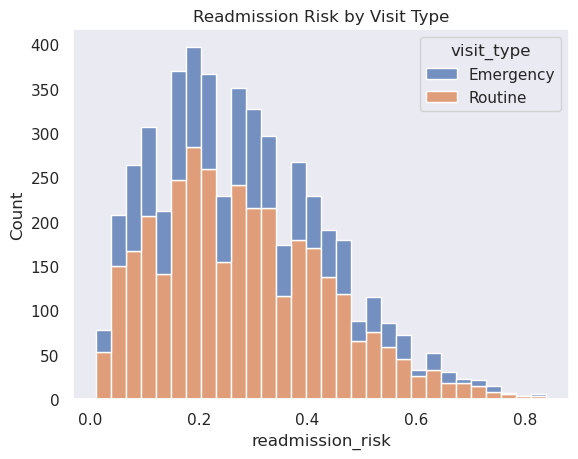

In [9]:
sns.histplot(
    data=df,
    x="readmission_risk",
    hue="visit_type",
    multiple="stack",
    bins=30
)
plt.title("Readmission Risk by Visit Type")
plt.savefig("Readmission Risk by Visit Type",dpi=100)
plt.show()

## Recovery Score by Visit Type (Kernel Density Estimation)

A KDE plot is a smooth version
of a histogram. Instead of bars, it creates smooth curves.

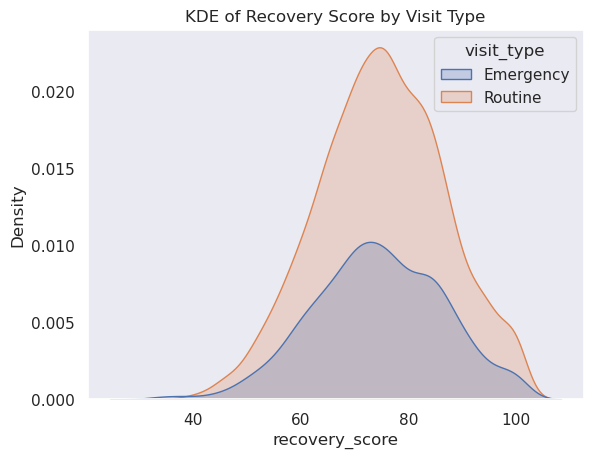

In [10]:
sns.kdeplot(
    data=df,
    x="recovery_score",
    hue="visit_type",
    fill=True
)
plt.title("KDE of Recovery Score by Visit Type")
plt.savefig("KDE of Recovery Score by Visit Type",dpi=100)
plt.show()

## Length of Stay Days (Empirical Cumulative Distribution Function)

It shows cumulative percentages.

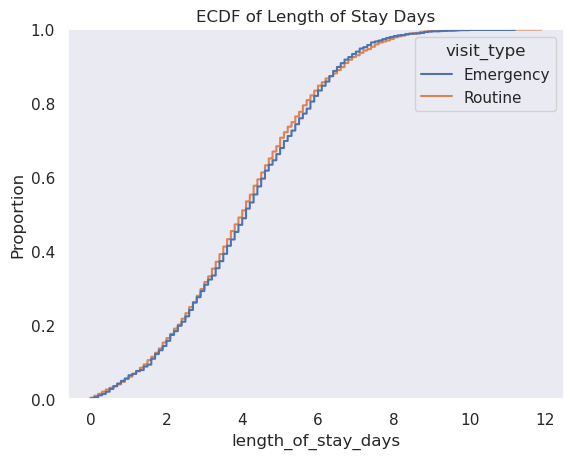

In [11]:
sns.ecdfplot(
    data=df,
    x="length_of_stay_days",
    hue="visit_type"
)
plt.title("ECDF of Length of Stay Days")
plt.savefig("ECDF of Length of Stay Days",dpi=100)
plt.show()

## Number of Visits by Treatment Type (COUNT PLOT)
A Count Plot shows frequency of categorical values.

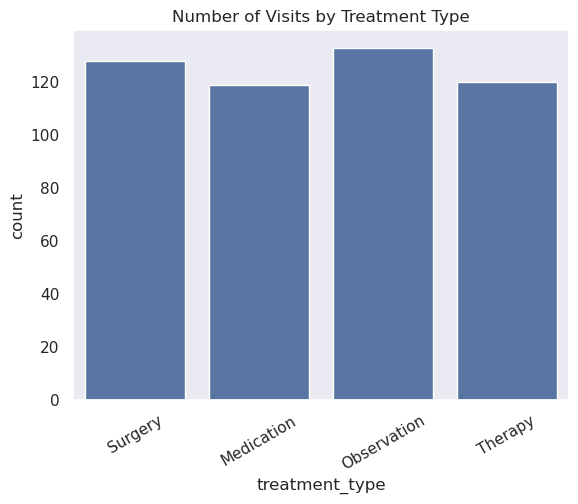

In [12]:
sns.countplot(
    data=ds,
    x="treatment_type"
)
plt.title("Number of Visits by Treatment Type")
plt.xticks(rotation=30)
plt.savefig("Number of Visits by Treatment Type",dpi=100)
plt.show()

## Average Treatment Cost by Department (BAR PLOT)

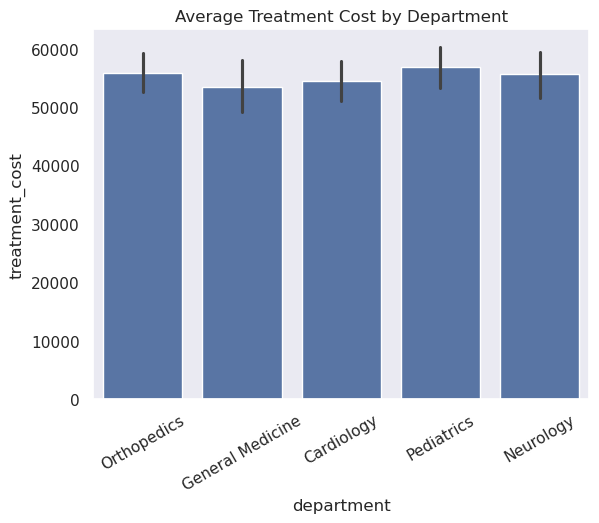

In [13]:
sns.barplot(
    data=ds,
    x="department",
    y="treatment_cost"
)
plt.xticks(rotation=30)
plt.title("Average Treatment Cost by Department")
plt.savefig("Average Treatment Cost by Department",dpi=100)
plt.show()

## Multiple Plots

### 📦 BOX PLOT

- Median: Middle value of data
- Quartiles: Data divided into 4 equal parts
- Outliers: Extreme unusual values

### 🎻 VIOLIN PLOT

A Violin Plot combines Box Plot & KDE Distribution. It shows:
- Data spread
- Distribution shape
- Density
- Symmetry

### 📍 STRIP PLOT
A Strip Plot shows every individual observation.
- `jitter=True:` Spreads overlapping points apart for better readability.

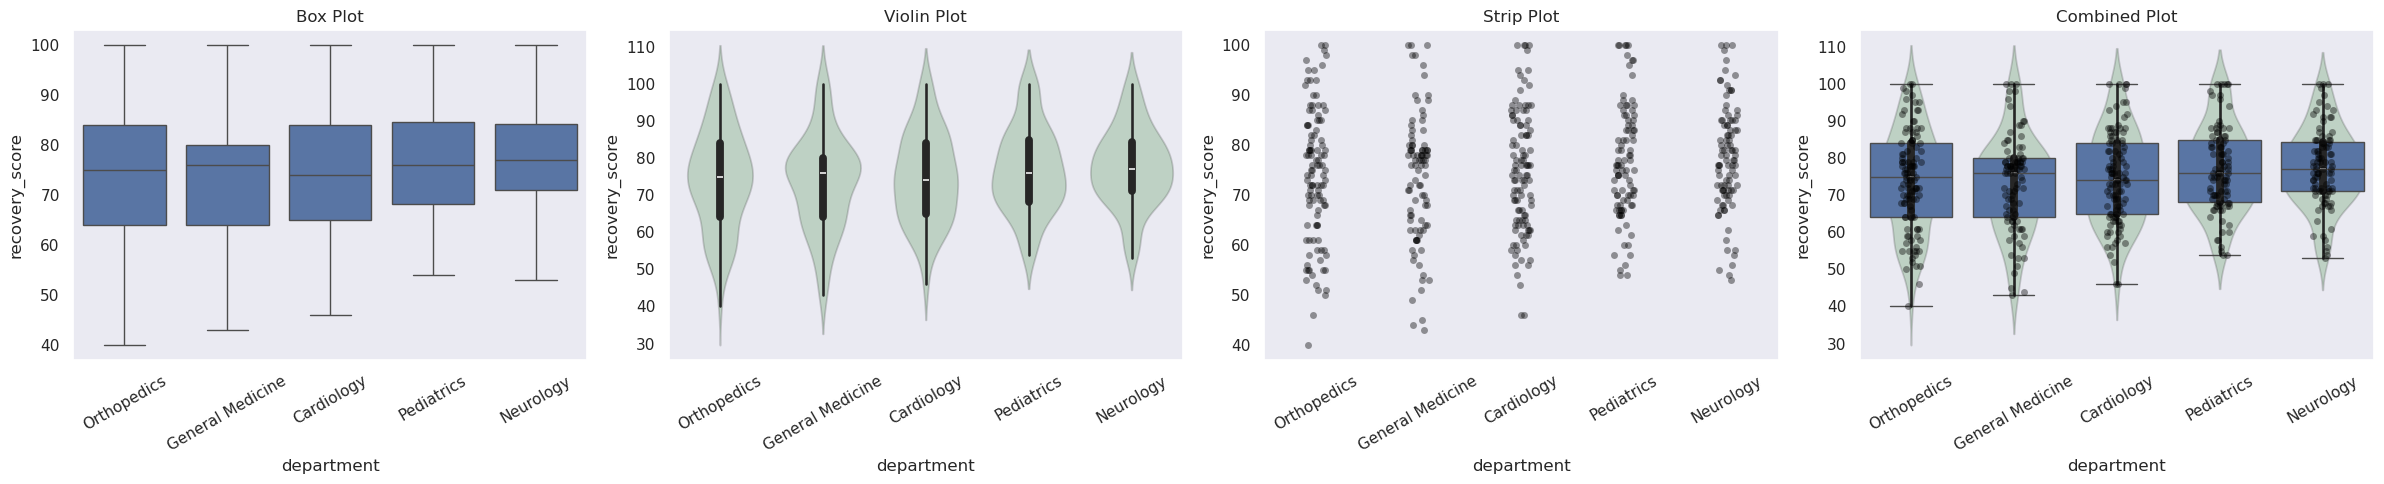

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 4 plots in 1 row
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1. Box Plot
sns.boxplot(
    data=ds,
    x="department",
    y="recovery_score",
    ax=axes[0]
)

axes[0].set_title("Box Plot")
axes[0].tick_params(axis='x', rotation=30)

# 2. Violin Plot
sns.violinplot(
    data=ds,
    x="department",
    y="recovery_score",
    color="green",
    alpha=0.2,
    ax=axes[1]
)

axes[1].set_title("Violin Plot")
axes[1].tick_params(axis='x', rotation=30)

# 3. Strip Plot
sns.stripplot(
    data=ds,
    x="department",
    y="recovery_score",
    jitter=True,
    color="black",
    alpha=0.4,
    ax=axes[2]
)

axes[2].set_title("Strip Plot")
axes[2].tick_params(axis='x', rotation=30)

# 4. Combined Plot
sns.boxplot(
    data=ds,
    x="department",
    y="recovery_score",
    ax=axes[3]
)

sns.violinplot(
    data=ds,
    x="department",
    y="recovery_score",
    color="green",
    alpha=0.2,
    ax=axes[3]
)

sns.stripplot(
    data=ds,
    x="department",
    y="recovery_score",
    jitter=True,
    color="black",
    alpha=0.4,
    ax=axes[3]
)

axes[3].set_title("Combined Plot")
axes[3].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("Department vs Recovery Score (Box, Violin, Strip) plots",dpi=100)
plt.show()

## CORRELATION MATRIX
Correlation measures how strongly two variables are related.
- +1  -> Perfect Positive Relationship
-  0  -> No Relationship
- -1  -> Perfect Negative Relationship

In [15]:
numeric_df=df[["length_of_stay_days","treatment_cost","recovery_score","readmission_risk"]]
numeric_df

,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,5.8,59151.0,59.0,0.12
1,5.1,30272.0,97.0,0.11
2,7.9,67498.0,60.0,0.19
3,5.0,29896.0,51.0,0.47
4,0.0,36208.0,60.0,0.40
...,...,...,...,...
4995,2.0,52402.0,54.0,0.54
4996,3.6,63973.0,58.0,0.39
4997,6.2,38100.0,89.0,0.25
4998,4.0,66931.0,66.0,0.28


In [16]:
corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)


Correlation Matrix:
                     length_of_stay_days  treatment_cost  recovery_score  \
length_of_stay_days             1.000000       -0.022281        0.012183   
treatment_cost                 -0.022281        1.000000       -0.014562   
recovery_score                  0.012183       -0.014562        1.000000   
readmission_risk               -0.000935        0.017822        0.002052   

                     readmission_risk  
length_of_stay_days         -0.000935  
treatment_cost               0.017822  
recovery_score               0.002052  
readmission_risk             1.000000  


## HEATMAP
A Heatmap uses colors to represent values.
- `This heatmap visualizes:`
  - Strong correlations
  - Weak correlations
  - Positive relationships
  - Negative relationships
- `annot=True:` Displays correlation values.
- `cmap="coolwarm":`
  - Red  -> Positive Correlation
  - Blue -> Negative Correlation

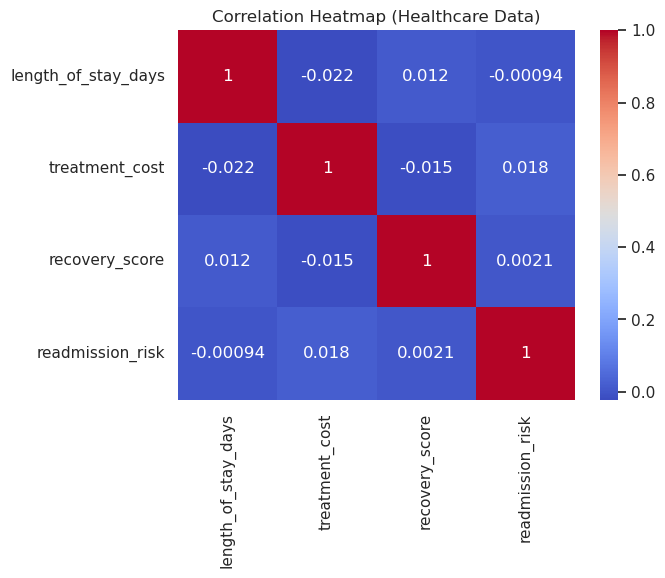

In [17]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (Healthcare Data)")
plt.savefig("Correlation Heatmap (Healthcare Data)",dpi=100)
plt.show()

### MASKED HEATMAP
A correlation matrix is symmetric.
- Example:
   - A vs B = B vs A
   - Showing both sides is repetitive. So we hide the upper triangle for cleaner visualization.
- `mask=mask:` Hides upper triangle values.
- Cleaner graph
- Easier readability
- Removes duplicate information

In [18]:
mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

print("\nMask Matrix:")
print(mask)


Mask Matrix:
[[ True  True  True  True]
 [False  True  True  True]
 [False False  True  True]
 [False False False  True]]


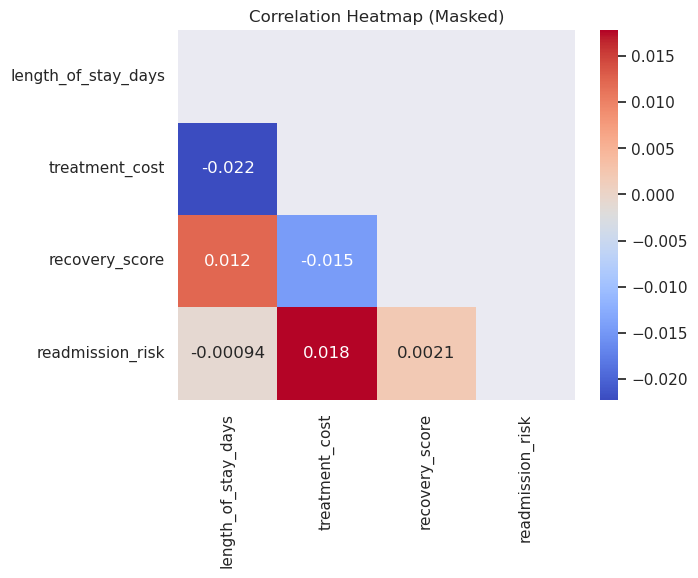

In [19]:
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap (Masked)")
plt.savefig("Correlation Heatmap (Masked)",dpi=100)
plt.show()